# pyJASPAR Notebook

Once you have installed pyJASPAR, you can load the module and connect to the latest release of JASPAR.

In [1]:
from pyjaspar import jaspardb

Connect to the version of JASPAR you're interested in. This will return jaspardb class object.
For example here we're getting the JASPAR2020.

In [2]:
jdb_obj = jaspardb(release='JASPAR2026')

You can also check JASPAR version you are connected to using:

In [3]:
print(jdb_obj.release)

JASPAR2026


By default it is set to latest release/version of JASPAR database. For example.

In [4]:
jdb_obj = jaspardb()
print(jdb_obj.release)

JASPAR2026


### Get available releases
You can find the available releases/version of JASPAR using.

In [5]:
print(jdb_obj.get_releases())

['JASPAR2026', 'JASPAR2024', 'JASPAR2022', 'JASPAR2020', 'JASPAR2018', 'JASPAR2016', 'JASPAR2014']


### Get motif by using JASPAR ID
If you want to get the motif details for a specific TF using the JASPAR ID. If you skip the version of motif, it will return the latest version. 

In [6]:
motif = jdb_obj.fetch_motif_by_id('MA0006.1')

Printing the motif will all the associated meta-information stored in the JASPAR database cluding the matric counts.

In [7]:
print(motif)

TF name	Ahr::Arnt
Matrix ID	MA0006.1
Collection	CORE
TF class	['Basic helix-loop-helix factors (bHLH)']
TF family	['PAS domain factors']
Species	10090
Taxonomic group	vertebrates
Accession	['P30561', 'P53762']
Data type used	SELEX
Medline	7592839
Comments	dimer
Matrix:
        0      1      2      3      4      5
A:   3.00   0.00   0.00   0.00   0.00   0.00
C:   8.00   0.00  23.00   0.00   0.00   0.00
G:   2.00  23.00   0.00  23.00   0.00  24.00
T:  11.00   1.00   1.00   1.00  24.00   0.00





Get the count matrix using `.counts`

In [8]:
print(motif.counts['A'])

[3.0, 0.0, 0.0, 0.0, 0.0, 0.0]


### Search motifs by TF name
You can use the `fetch_motifs_by_name` function to find motifs by TF name. This method returns a list of motifs for the same TF name across taxonomic group. For example, below search will return two CTCF motifs one in vertebrates and another in plants taxon.

In [9]:
motifs = jdb_obj.fetch_motifs_by_name("CTCF")

In [10]:
print(len(motifs))

4


In [11]:
print(motifs)

TF name	CTCF
Matrix ID	MA0531.2
Collection	CORE
TF class	['C2H2 zinc finger factors']
TF family	['More than 3 adjacent zinc fingers']
Species	7227
Taxonomic group	insects
Accession	['Q9VS55']
Data type used	ChIP-chip
Medline	17616980
Matrix:
        0      1      2      3      4      5      6      7      8      9
A: 257.00 1534.00 202.00 987.00   2.00   0.00   2.00 124.00   1.00  79.00
C: 714.00   1.00   0.00   0.00   4.00   0.00   0.00 1645.00   0.00 1514.00
G:  87.00 192.00 1700.00 912.00 311.00 1902.00 1652.00   3.00 1807.00   8.00
T: 844.00 175.00   0.00   3.00 1585.00   0.00 248.00 130.00  94.00 301.00



TF name	CTCF
Matrix ID	MA0139.2
Collection	CORE
TF class	['C2H2 zinc finger factors']
TF family	['More than 3 adjacent zinc fingers']
Species	9606
Taxonomic group	vertebrates
Accession	['P49711']
Data type used	ChIP-seq
Medline	17512414
Comments	TF has several motif variants.
Matrix:
        0      1      2      3      4      5      6      7      8      9     10     11     12    

### Search motifs with 
A more commonly used function is `fetch_motifs` helps you to get motifs which match a specified set of criteria.
You can query the database based on the available meta-information in the database.

For example, here we are gettting the widely used CORE collection for vertebrates. It returns a list of non-redundent motifs. 

In [12]:
motifs = jdb_obj.fetch_motifs(
collection = ['CORE'],
tax_group = ['Vertebrates'],
all_versions = False,
)

In [13]:
print(len(motifs))

1019


In [14]:
for motif in motifs:
    #print(motif.matrix_id)
    pass # do something with the motif

Get the number of non-redundent motifs from CORE collection per-release.

In [15]:
for release in jdb_obj.get_releases():
    print(release)
    jdb_obj = jaspardb(release=release)
    motifs = jdb_obj.fetch_motifs(
        collection = ["CORE"],
        all_versions = False,
        #species = '10090' # this is the mouse tax ID
    )
    print(len(motifs))

JASPAR2026
2633
JASPAR2024
2346
JASPAR2022
1956
JASPAR2020
1646
JASPAR2018
1404
JASPAR2016
1082
JASPAR2014
593


### Analysis module

In [16]:
jdb_obj = jaspardb(release="JASPAR2026")

#### similarity/correlation

In [17]:
from pyjaspar.analysis import pearson_correlation, best_correlation

m1 = jdb_obj.fetch_motif_by_id("MA0001.1")
m2 = jdb_obj.fetch_motif_by_id("MA0002.1")

# Column-wise Pearson correlation
score = pearson_correlation(m1, m2)

# Best alignment across all offsets and orientations
score, offset, is_rc = best_correlation(m1, m2)
score

0.6692418299461174

#### Scan a sequence for motif occurrences

In [18]:
from pyjaspar.analysis import scan_sequence

sequence = "CCACCAGGTGGCACTAGCACCAGGTGGTATCTAGTGGACCTAGCATTGCTATTACGTCA"
scan_target_motif = jdb_obj.fetch_motif_by_id("MA0139.2")
print("Consensus motif: ", scan_target_motif.consensus)

hits = scan_sequence(sequence, scan_target_motif, threshold=0.7)

print(f"{len(hits)} hit(s) found")
for hit in hits[:3]:
    print(hit)

Consensus motif:  GCCACCAGGGGGCGC
8 hit(s) found
ScanHit(position=2, strand='+', score=-10.198715209960938, sequence='ACCAGGTGGCACTAG')
ScanHit(position=15, strand='+', score=8.533143997192383, sequence='AGCACCAGGTGGTAT')
ScanHit(position=16, strand='+', score=-13.91905689239502, sequence='GCACCAGGTGGTATC')


#### Motif enrichment

In [19]:
from pyjaspar.analysis import motif_enrichment

candidate_motifs = jdb_obj.fetch_motifs(tf_family="Homeo", collection=None, all_versions=False)
for m in candidate_motifs:
    print(m.matrix_id, m.name, m.consensus)

foreground = [
    "GGCGATTTATTACGCG",
    "ATGCATTTATTAGGCA",
    "CGTATTTATTACGATA",
    "TACGTTTATTAGCATG",
    "GATCTTTATTACTGAC",
]
background = [
    "GGCGACCCGGGACGCG",
    "ATGCACCCGGGAGGCA",
    "CGTACCCGGGACGATA",
    "TACGCCCGGGAGCATG",
    "GATCCCCGGGACTGAC",
]

results = motif_enrichment(foreground, background, motifs=candidate_motifs, threshold=0.9)
for r in results:
    print("\n", r)

MA0174.1 Dbx TTTATTA
MA0247.3 tin TTCAAGTGG
MA2485.1 Duxbl1 TTAATCTAATCAA

 EnrichmentResult(motif_id='MA0174.1', motif_name='Dbx', fg_hits=5, bg_hits=0, fg_total=5, bg_total=5, fold_enrichment=inf, pvalue=np.float64(0.003968253968253969), qvalue=np.float64(0.011904761904761908))

 EnrichmentResult(motif_id='MA0247.3', motif_name='tin', fg_hits=0, bg_hits=0, fg_total=5, bg_total=5, fold_enrichment=1.0, pvalue=1.0, qvalue=1.0)

 EnrichmentResult(motif_id='MA2485.1', motif_name='Duxbl1', fg_hits=0, bg_hits=0, fg_total=5, bg_total=5, fold_enrichment=1.0, pvalue=1.0, qvalue=1.0)


### Visualization
`plot_logo` draws a motif as a sequence logo (requires `pip install pyjaspar[viz]`).

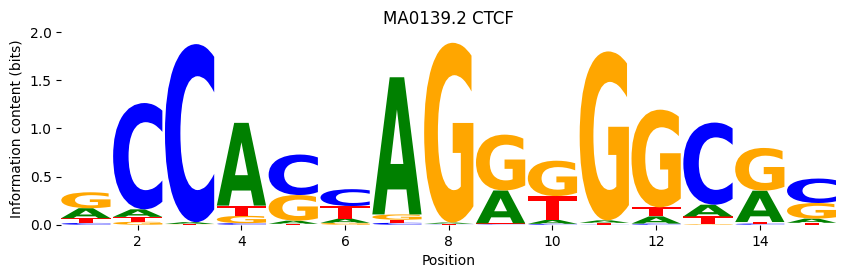

In [20]:
from pyjaspar.viz import plot_logo

motif = jdb_obj.fetch_motif_by_id("MA0139.2")  # CTCF, human
logo = plot_logo(motif)
logo.ax.set_title(f"{motif.matrix_id} {motif.name}");

### Deep Learning (DL) collection

In [21]:
from pyjaspar import JasparDB

jdb = JasparDB()

# Fetch a TF profile
profile = jdb.dl.fetch_profile("DL0001.1")

print(profile.tf_name, profile.tax_group)

print(profile.primary_motif.pfm.length)

# Fetch a BPNet model with its motifs
model = jdb.dl.fetch_model("BP000001.1")
print(model.tf_name, model.cell_line, len(model.motifs))

# Fetch a single motif pattern
motif = jdb.dl.fetch_motif_pattern("MO000001.1")

print(motif.matrices.keys())  # dict_keys(['PFM', 'CWM'])
print(motif.matrices["PFM"])

# Convert PFM to BioPython Motif object
bio_motif = motif.to_biopython()
print(bio_motif.pssm)

# Search profiles and models
profiles = jdb.dl.search_profiles(tf_name="REST")
models = jdb.dl.search_models(cell_line="K562")


ARNT2 vertebrates
14
REST K562 6
dict_keys(['CWM', 'PFM'])
Matrix(kind='PFM', values=array([[3.300e+02, 3.850e+02, 3.340e+02, 4.350e+02, 4.530e+02, 4.930e+02,
        5.300e+02, 2.060e+02, 6.000e+00, 2.020e+03, 0.000e+00, 0.000e+00,
        6.300e+01, 0.000e+00],
       [6.990e+02, 7.880e+02, 6.870e+02, 6.960e+02, 6.680e+02, 3.890e+02,
        3.050e+02, 9.120e+02, 2.158e+03, 4.300e+01, 2.166e+03, 0.000e+00,
        2.600e+01, 2.000e+00],
       [8.380e+02, 5.670e+02, 6.490e+02, 7.470e+02, 7.220e+02, 1.039e+03,
        1.193e+03, 6.240e+02, 2.000e+00, 2.900e+01, 0.000e+00, 2.167e+03,
        6.200e+01, 2.162e+03],
       [3.000e+02, 4.270e+02, 4.970e+02, 2.890e+02, 3.240e+02, 2.460e+02,
        1.390e+02, 4.250e+02, 1.000e+00, 7.500e+01, 1.000e+00, 0.000e+00,
        2.016e+03, 3.000e+00]]))
        0      1      2      3      4      5      6      7      8      9     10     11     12     13
A:  -0.72  -0.49  -0.70  -0.32  -0.26  -0.14  -0.03  -1.39  -6.50   1.90   -inf   -inf  -3.10   

In [22]:
# Search profiles by TF name and combined filters
models = jdb.dl.search_models(tf_name="REST", cell_line="K562")
for m in models:
    print(f"{m.model_id}: {m.tf_name} ({m.cell_line}) ({m.tax_id})")

BP000001.1: REST (K562) (9606)
BP000017.1: REST (K562) (9606)
BP000063.1: REST (K562) (9606)
BP000075.1: REST (K562) (9606)
